## Workshop Day 2: Simulating River Transport Systems

In this notebook, we will investigate how tidal windows and traffic rules affect traffic in the Río de la Plata. 

### Importing packages and set path
We start by importing the required packages and specific objects and functions from certain packages.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx

# packages(s) used to navigate folders
from pathlib import Path

# package(s) related to the hydrodynamics and tidal windows
import xarray as xr

# load OpenTNSim modules
from opentnsim.core import ExtraMetadata
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.visualizations import generate_vessel_gantt_chart
from opentnsim.environment.mixins.hydrodynamics import HydrodynamicData, HydrodynamicDataManager
from opentnsim.graph.visualizations import plot_graph_folium
from opentnsim.port.mixins.anchorage_area import IsAnchorage, CanWaitAtAnchorage
from opentnsim.port.mixins.port import IsPort, HasPortAccess
from opentnsim.port.mixins.rules import Rule, TrafficRules
from opentnsim.port.mixins.tidal_accessibility import HasDraughtRestrictions
from opentnsim.port.mixins.waterway import IsWaterway, WaterwayTraversable
from opentnsim.port.utils import (
    add_ukc_policy_to_edge, 
    add_traffic_encountering_restriction_to_edge, 
    add_traffic_encountering_exception_to_edge,
    add_traffic_overtaking_restriction_to_edge, 
    add_traffic_reservation_to_edge,
    )
from opentnsim.port.visualizations import plot_time_distance_diagram_multi

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import pickle
from itertools import combinations

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np

# check the version of OpenTNSim
import opentnsim
print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.3.2a2.dev3+g514a752b4.d20260603


In [2]:
# we will also set our path
cmd = Path().cwd()
data_dir = cmd / Path('data/')
print(data_dir)

C:\Users\floorbakker\OpenTNSim\notebooks\student_notebooks\workshops\AADIP - 2026\data


#### 0. Create environment

In [3]:
# Define the simulation start and stop times
simulation_start = datetime.datetime(2020, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2020, 1, 4, 0, 0, 0)

In [4]:
# Create the environment and set specific attributes: simulation_start, simulation_stop, and epoch.
env = simpy.Environment(initial_time=simulation_start.timestamp())

env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

#### 1. Create graph
Next, we load a pre-prepared network (a graph) of the Hídrovia and add it to the environment.

In [5]:
# load graph of the Hídrovia 
filename = 'graph_RdlP.pkl'
with open(data_dir / filename, 'rb') as f:
    graph = pickle.load(f)

In [6]:
# add graph to environment
env.graph = graph

For visualization purposes, we also load the port and waterway infrastructure.

In [7]:
# anchorage areas (zonas de espera)
filename = 'anchorage_areas_RdlP.pickle'
anchorage_areas = pd.read_pickle(data_dir / filename)

In [8]:
# berths (terminals)
filename = 'berths_RdlP.pickle'
berths = pd.read_pickle(data_dir / filename)

In [9]:
# turning basins (zonas de maniobras)
filename = 'turning_basins_RdlP.pickle'
turning_basins = pd.read_pickle(data_dir / filename)

Creating interactive plot

In [10]:
m = plot_graph_folium(graph, longitude=-58.1, latitude=-34, zoom_start = 8, 
                      berths = berths, turning_basins = turning_basins, anchorage_areas = anchorage_areas)
m

#### 1a. Adding hydrodynamic data
We specify the locations of the determinantes (tidal window locations defined at points)

In [11]:
determinantes = {
    ('Punta Indio KM_150', 'Punta Indio KM_182.7'): 155000-150000, # Determinante at km 155.0
    ('Intermedio KM_81', 'Intermedio KM_99'): 83000-81000, # Determinante at km 83.0
    ('Rada exterior KM_56', 'Paso Banco Chico KM_59'): 58400-56000, # Determinante at km 58.4
}

We need to add tidal water levels and maintained bed levels to the simulation

In [12]:
# loading tidal water levels at the determinantes
filename = 'hydrodynamic_data_RdlP.nc'
hydrodynamic_data = xr.open_dataset(data_dir / filename)

Plotting hydrodynamic data

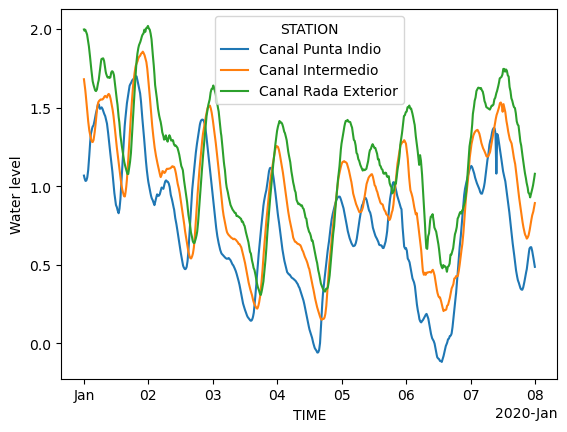

In [13]:
hydrodynamic_data['Water level'].plot(x='TIME', hue='STATION');

In [14]:
# we replace the original station names with the edges of the determinantes
stations = np.empty(len(determinantes), dtype=object)
for i, e in enumerate(determinantes):
    stations[i] = tuple(e)

hydrodynamic_data = hydrodynamic_data.assign_coords(
    STATION=("STATION", stations)
)

In [15]:
# add the data to the environment
HydrodynamicData(
    env=env, 
    hydrodynamic_data=hydrodynamic_data
);

#### UKC Policy
We specify the UKC policy for the Hídrovia

In [16]:
def ukc_policy(vessel):
    draught = vessel.T
    if draught < 10.36:
        return 0.6
    elif draught <= 10.67:
        return 0.6 + (draught - 10.37) * 100 * 0.015
    else:
        return draught * 0.1

We add the UKC policy to the edges of the graph at which there is a determinante

In [17]:
for edge, distance_of_series in determinantes.items():
    # we create a list of Rule-objects that have a condition, policy, and name
    rules = [
        Rule(
            condition=lambda vessel: vessel.T >= 0., # condition (draught > 0, meaning the policy holds for all vessel)
            policy=ukc_policy, # policy
            name='ukc',
        ),
    ]

    # a built-in function that adds the rule(s) to the defined edge of the environment's graph
    add_ukc_policy_to_edge(
        graph=env.graph,
        edge=edge,
        rules=rules,
        distance_of_series = distance_of_series,
    )

#### 1b Adding infrastructures


##### Port authority
We create a port authority with the node "Zona De Alijo" as the entry node to the port (from the ocean)

In [18]:
port = IsPort(
    env=env, 
    name = "Rio de la Plata", 
    port_entry_nodes=['Zona De Alijo']
)

##### Anchorage areas

In [19]:
ponton_recalada = IsAnchorage(
    env=env, capacity=100, 
    name = 'Zona Recalada', 
    node = 'Ponton Recalada', 
    depth = 20, #a fictive depth of the anchorage areas in [m]
    geometry=env.graph.nodes['Ponton Recalada']['geometry'], 
    port = port
)

intermedio_km99 = IsAnchorage(
    env=env, capacity=20, 
    name = 'Zona de Fondeo y Espera Banco Chico', 
    node = 'Intermedio KM_99', 
    depth = 20, #a fictive depth of the anchorage areas in [m]
    geometry=env.graph.nodes['Intermedio KM_99']['geometry'], 
    port = port
)

zona_comun = IsAnchorage(
    env=env, 
    capacity=100, 
    name = 'Zona de Fondeo y Espera de Practicaje', 
    node = 'Rada La Plata - Zona Comun', 
    depth = 20, #a fictive depth of the anchorage areas in [m]
    geometry=env.graph.nodes['Rada La Plata - Zona Comun']['geometry'], 
    port = port
)

##### Waterways
We start by defining priority rules for vessels

In [20]:
def priority_rules(vessel):
    priority = 0
    if vessel.type == "Passenger": # cruise vessels have the highest priority
        priority = 2
    elif vessel.T >= 10.2: # tide-bound vessels the second highest
        priority =  1
    if vessel.bound == 'outbound': # outbound vessels have higher priority than inbound vessels
        priority += 0.5
    return priority

Create the waterways in between the anchorage areas

In [21]:
canal_punta_indio = IsWaterway(env=env,
                               port = port,
                               name='Canal Punta Indio',
                               node_start='Intermedio KM_99',
                               node_stop='Ponton Recalada',
                               safety_margin = pd.Timedelta(minutes=20),
                               priority_rules = lambda vessel: priority_rules(vessel))

canal_intermedio = IsWaterway(env=env,
                              port = port,
                              name='Canal Intermedio',
                              node_start='Rada La Plata - Zona Comun',
                              node_stop='Intermedio KM_99',
                              safety_margin = pd.Timedelta(minutes=20),
                              priority_rules = lambda vessel: priority_rules(vessel))

##### Operation rules

We define the following restrictions

In [22]:
# all vessels cannot encounter/overtake each other, except class C vessels (which sail along the canal)
def restriction_5_1_1(vessel_1, vessel_2):
    return (
        vessel_1.B >= 0.0 
        and vessel_2.B >= 0.0 
        and (vessel_1.classification != 'C' and vessel_2.classification != 'C')
    )

# two class A vessels cannot encounter each other
def restriction_5_1_2(vessel_1, vessel_2):
    return (
        vessel_1.classification == 'A'
        and vessel_2.classification == 'A'
    )

# a vessel with a length greater than 340 m or a beam greater than 49 m cannot overtake/encounter any other vessel
def restriction_5_1_3(vessel_1, vessel_2):
    return (
        (vessel_1.L > 340.0 or vessel_1.B > 49.0)
        and vessel_2.B >= 0.0 
        and (vessel_1.classification != 'C' and vessel_2.classification != 'C')
    )

We also define which vessels require reservation of the canal

In [23]:
def reservation_punta_indio(vessel):
    return (
        (vessel.type == 'Passenger' or vessel.type == 'GNL')
        and vessel.T >= 7.32)

Now, we create a dictionary of what restrictions hold for each part of the network

In [24]:
# 1. Encountering and overtaking
restrictions_dict = {
    ('Punta Indio KM_140.8', 'Punta Indio KM_150'): [
        Rule(
            condition=lambda vessels: any(
                restriction_5_1_1(v1, v2)
                or restriction_5_1_1(v2, v1)
                for v1, v2 in combinations(vessels, 2)
            ),
            policy=TrafficRules.prohibited,
            name = '5.1.1',
        )
    ],
    ('Punta Indio KM_210', 'Punta Indio KM_216'): [
        Rule(
            condition=lambda vessels: any(
                (restriction_5_1_1(v1, v2)
                 or restriction_5_1_1(v2, v1))
                for v1, v2 in combinations(vessels, 2)
            ),
            policy=TrafficRules.prohibited,
            name = '5.1.1',
        )
    ],
    ('Punta Indio KM_150', 'Punta Indio KM_182.7'): [
        Rule(
            condition=lambda vessels: any(
                restriction_5_1_2(v1, v2)
                or restriction_5_1_2(v2, v1)
                for v1, v2 in combinations(vessels, 2)
            ),
            policy=TrafficRules.prohibited,
            name = '5.1.2',
        )
    ],
    ('Punta Indio KM_194.4', 'Punta Indio KM_201.6'): [
        Rule(
            condition=lambda vessels: any(
                restriction_5_1_2(v1, v2)
                or restriction_5_1_2(v2, v1)
                for v1, v2 in combinations(vessels, 2)
            ),
            policy=TrafficRules.prohibited,
            name = '5.1.2',
        )
    ],
    ('Intermedio KM_118.5', 'Ponton Recalada'): [
        Rule(
            condition=lambda vessels: any(
                restriction_5_1_3(v1, v2)
                or restriction_5_1_3(v2, v1)
                for v1, v2 in combinations(vessels, 2)
            ),
            policy=TrafficRules.prohibited,
            name = '5.1.3',
        )
    ],
}

# 2. Reservations
reservations_dict = {
    ('Punta Indio KM_150', 'Punta Indio KM_201.6'): [
        Rule(
            condition=lambda vessel: reservation_punta_indio(vessel),
            policy=TrafficRules.prohibited,
            name = 'reservation',
            ),
    ],
}

Last, we add the rules to the environment

In [25]:
for edge, restrictions in restrictions_dict.items():
    add_traffic_encountering_restriction_to_edge(
        graph=env.graph,
        edge=edge,
        rules=restrictions
    )

for edge, restrictions in restrictions_dict.items():
    add_traffic_overtaking_restriction_to_edge(
        graph=env.graph,
        edge=edge,
        rules=restrictions
    )

for edge, reservation in reservations_dict.items():
    add_traffic_reservation_to_edge(
        graph=env.graph,
        edge=edge,
        rules=reservation
    )

#### 2. Create agents
We create vessels making a preferred Vessel class out of available mix-ins

In [26]:
Vessel = type(
    "Vessel", 
    (
        WaterwayTraversable,
        HasPortAccess,
        CanWaitAtAnchorage,
        HasDraughtRestrictions,
        ExtraMetadata
    ),
    {}
)

We wrote a function to create a vessel 

In [27]:
def create_vessel(
    name,                   # name
    route,                  # route
    v,                      # sailing speed over ground
    L,                      # length
    B,                      # beam
    T,                      # draught
    classification,         # vessel class
    bound = 'inbound',      # direction
    vessel_type = 'Tanker', # type
    arrival_time = simulation_start, #time of arrival at the port
):
    data_vessel = {"env": env,                                        # needed for simpy simulation
                   "name": name,                                      # required by Identifiable
                   "geometry": env.graph.nodes[route[0]]['geometry'], # required by Locatable
                   "route": route,                                    # required by Routeable
                   "v": v,                                            # required by Movable, 1 m/s to check if the distance is covered in the expected time
                   "bound": bound,
                   "type":vessel_type,
                   "L":L,
                   "B":B,
                   "T":T,
                   "arrival_time":arrival_time,
                   }
    vessel = Vessel(**data_vessel)
    vessel.classification = classification
    return vessel

We also defined a mission for the vessels

In [28]:
def mission(vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    yield from vessel.move()

To create the vessels, we use vessels that we observed from AIS data

In [29]:
vessels = pd.read_pickle(data_dir / 'vessels_RdlP.pkl')
vessels

,mmsi,time_start,draught,bound,preceding_waiting_time,ship_type,ship_class,length,beam,color,trip_number,name
0,431190000,2020-01-01 00:39:57.948,8.8,outbound,0 days 00:00:00,RoRo,B,199.0,32.0,#E1251B,1,431190000 (1)
1,304251000,2020-01-01 00:52:51.536,7.8,outbound,0 days 00:00:00,RoRo,B,120.0,20.0,#E1251B,1,304251000 (1)
2,412478720,2020-01-01 01:56:08.289,6.9,outbound,0 days 00:00:00,,B,190.0,29.0,#E1251B,1,412478720 (1)
3,538002631,2020-01-01 03:49:41.821,6.8,inbound,0 days 06:00:00,Dry bulk,B,229.0,32.0,#E1251B,1,538002631 (1)
4,357628000,2020-01-01 03:52:38.161,9.7,outbound,0 days 00:00:00,Liquid bulk,A,229.0,33.0,#00A9E0,1,357628000 (1)
...,...,...,...,...,...,...,...,...,...,...,...,...
126,248945000,2020-01-06 19:44:53.760,6.8,outbound,0 days 06:00:00,RoRo,B,190.0,32.0,#E1251B,2,248945000 (2)
127,477369100,2020-01-06 20:57:06.576,10.5,outbound,0 days 06:00:00,Dry bulk,A,200.0,32.0,#00A9E0,2,477369100 (2)
128,538007656,2020-01-06 22:31:57.722,8.4,inbound,0 days 00:00:00,Dry bulk,B,199.0,32.0,#E1251B,1,538007656 (1)
129,229381000,2020-01-06 23:12:43.563,9.9,outbound,0 days 06:00:00,Dry bulk,A,177.0,26.0,#00A9E0,1,229381000 (1)


We can create interesting plots:

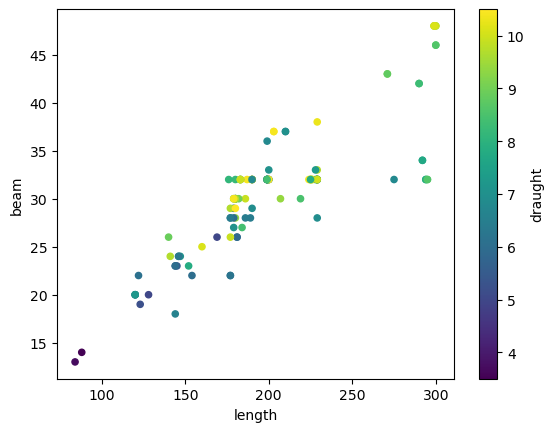

In [30]:
# vessel characteristics
vessels.plot.scatter(x='length',y='beam', c='draught');

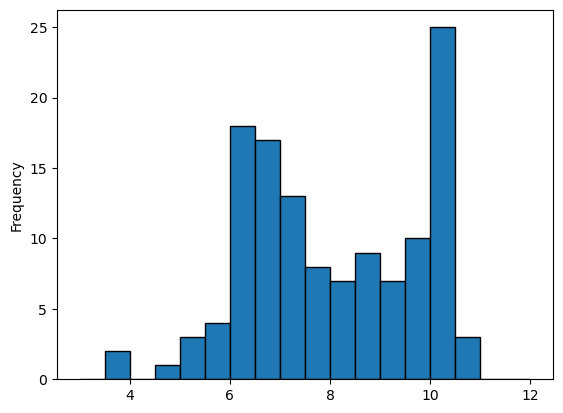

In [31]:
vessels['draught'].plot.hist(bins=np.arange(3,12.5,0.5),edgecolor='k');

We create and add the vessels to the environment:

In [32]:
inbound_route = nx.dijkstra_path(env.graph, "Ponton Recalada", "Rada La Plata - Zona Comun")
outbound_route = nx.dijkstra_path(env.graph, "Rada La Plata - Zona Comun", "Ponton Recalada")

# looping over the observed vessels
for _, vessel_info in vessels.iterrows():
    if vessel_info.time_start < simulation_start or vessel_info.time_start > simulation_stop:
        continue

    # reading input parameters of vessel
    name = str(vessel_info.mmsi) + f' ({vessel_info.trip_number})'               # creating name
    route = inbound_route if vessel_info.bound == 'inbound' else outbound_route  # creating route
    length = vessel_info.length                                                  # length [m]
    beam = vessel_info.beam                                                      # beam [m]
    draught = vessel_info.draught                                                # draught [m]
    arrival_time = vessel_info.time_start                                        # arrival time
    vessel_type = vessel_info.ship_type                                          # vessel type
    classification = vessel_info.ship_class                                      # vessel class
    v = 5.5                                                                      # speed over ground as observed in data, in [m/s] 

    # creating the vessel
    vessel = create_vessel(name = name, 
                           route = route, 
                           v=v, 
                           L = length, 
                           B = beam, 
                           T = draught, 
                           vessel_type = vessel_type,
                           arrival_time = arrival_time, 
                           classification = classification)

    # adding vessel to the environment using env.process()
    vessel.mission = env.process(mission(vessel))

#### 3. Run simulation
We run the environment

In [33]:
env.run()

In [34]:
env.vessels_orig = env.vessels
try:
    env.vessels = {vessel.name: vessel for vessel in env.vessels.values()}
except:
    pass

#### 4. Inspect output

##### Tidal windows

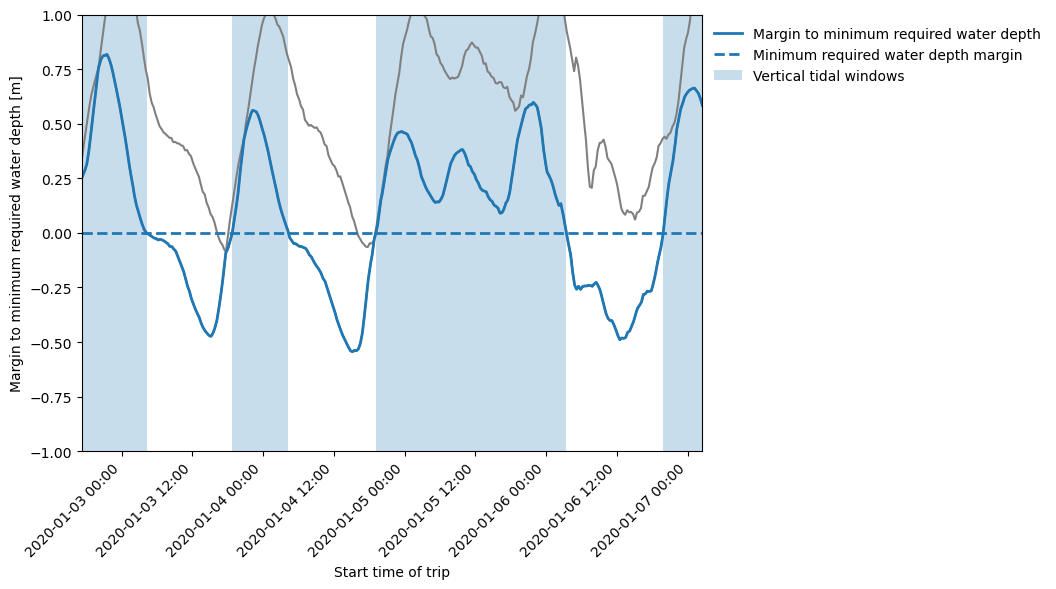

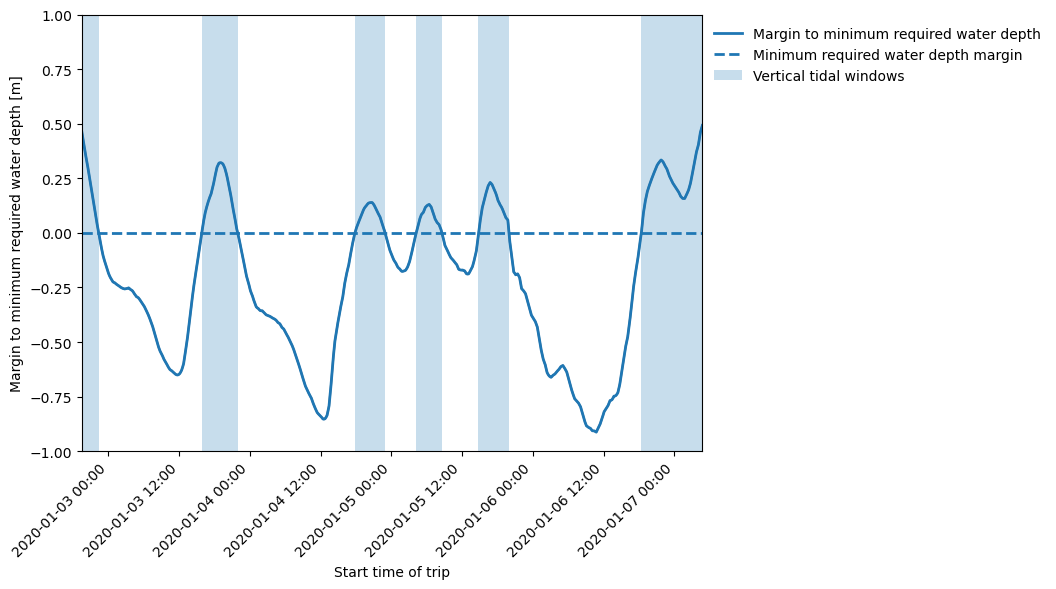

In [35]:
trip_index = 0
vessel = env.vessels['564585000 (1)']
fig = vessel.plot_tidal_windows(trip_index=trip_index, canal = 'Canal Punta Indio', plot_all = True);

##### Time-distance diagram
We define two functions that help us to better visualize the vessels over time and distance.

In [36]:
def determine_vessel_class(vessel = None, vessel_data = None):
    if vessel_data is not None:
        T = vessel_data.get('T', None)

    if vessel is not None:
        T = vessel.T
        
    if T >= 8.84:
        vessel_class = 'A'
    elif T >= 6.40:
        vessel_class = 'B'
    else:
        vessel_class = 'C'
    return vessel_class

def color_function(vessel):
    vessel_class = determine_vessel_class(vessel = vessel)
    color = '#0F68AE'
    if vessel_class == 'A':
        color = '#00AFDD'
    elif vessel_class == 'B':
        color = '#E6362A'
    if vessel.type == 'Passenger' and vessel.T > 7.5:
        color = '#000000'
    return color

We can create the time-distance plot like this:

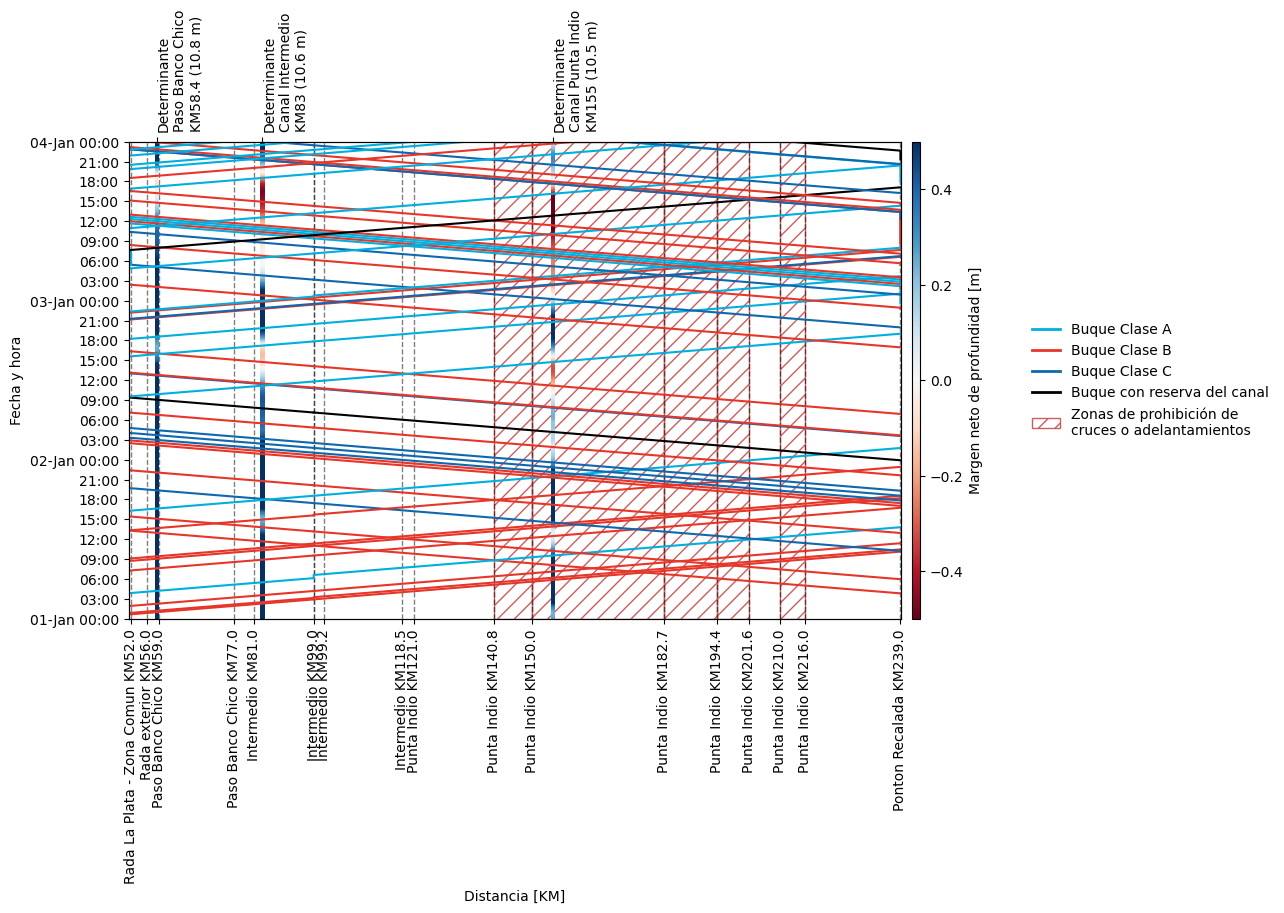

In [37]:
fig,_ = plot_time_distance_diagram_multi(
    [canal_intermedio, canal_punta_indio],
    hydrodynamic_data = hydrodynamic_data,
    determinantes = determinantes,
    time_start = simulation_start,
    time_end = simulation_stop,
    draught = 10.5,
    hydro_property = 'Margen neto de seguridad mínimo bajo la quilla [m]',
    start_distance = 52000,
    vessels_to_show_rules = ['636017137 (1)', '355931000 (1)', '636017137 (1)'],
    show_rules = True,
    color_function = color_function,
    offset = 250,
    xlim = [51500,239500],
    figsize = (12,3*int((simulation_stop - simulation_start)/pd.Timedelta(days=1)))
)

##### Delays
We create a waiting event dataframe for all the vessels, using their logbook in which the waiting times and reasons are logged.

In [38]:
pd.DataFrame.from_dict(list(env.vessels.values())[-1].logbook)

,Message,Timestamp,Value,Geometry
0,Sailing from node Rada La Plata - Zona Comun t...,2020-01-03 22:50:34.085000,0.000000,POINT (-57.8180554940665 -34.71452979040823)
1,Sailing from node Rada La Plata - Zona Comun t...,2020-01-03 23:02:31.037791,3943.240350,POINT (-57.77651429630031 -34.72384588037793)
2,Sailing from node Rada exterior KM_56 to node ...,2020-01-03 23:02:31.037791,3943.240350,POINT (-57.77651429630031 -34.72384588037793)
3,Sailing from node Rada exterior KM_56 to node ...,2020-01-03 23:11:23.169507,6869.964787,POINT (-57.74567889389403 -34.73076107297025)
4,Sailing from node Paso Banco Chico KM_59 to no...,2020-01-03 23:11:23.169507,6869.964787,POINT (-57.74567889389403 -34.73076107297025)
5,Sailing from node Paso Banco Chico KM_59 to no...,2020-01-04 00:07:06.961009,25260.818049,POINT (-57.55033264383051 -34.767878063877895)
6,Sailing from node Paso Banco Chico KM_77 to no...,2020-01-04 00:07:06.961009,25260.818049,POINT (-57.55033264383051 -34.767878063877895)
7,Sailing from node Paso Banco Chico KM_77 to no...,2020-01-04 00:21:43.712096,30082.949026,POINT (-57.503312538772654 -34.78645336422924)
8,Sailing from node Intermedio KM_81 to node Int...,2020-01-04 00:21:43.712096,30082.949026,POINT (-57.503312538772654 -34.78645336422924)
9,Sailing from node Intermedio KM_81 to node Int...,2020-01-04 01:05:31.612095,44536.399020,POINT (-57.36849553139489 -34.8543680443966)


In [39]:
# we loop over the vessels and extract the waiting events
waiting = []
for vessel in env.vessels.values():
    logbook = pd.DataFrame.from_dict(vessel.logbook) 
    active = {}
    for _, row in logbook.iterrows():
        event = row["Message"]      # or whatever your event column is called
        time = row["Timestamp"]
    
        if event.startswith("Waiting for "):
            if event.endswith(" start"):
                reason = event[len("Waiting for "):-len(" start")]
                active[reason] = row
    
            elif event.endswith(" stop"):
                reason = event[len("Waiting for "):-len(" stop")]
    
                if reason in active:
                    start = active.pop(reason)
    
                    waiting.append({
                        "vessel": vessel.id,
                        "draught": vessel._T,
                        "reason": reason,
                        "start": start["Timestamp"],
                        "stop": time,
                        "waiting_time": time - start["Timestamp"],
                    })

waiting_df = pd.DataFrame(waiting)
waiting_df['name'] = waiting_df.vessel.apply(lambda x: env.vessels_orig[x].name)
waiting_df["waiting_hours"] = waiting_df["waiting_time"].dt.total_seconds() / 3600
waiting_df["bound"] = waiting_df["name"].apply(lambda x: vessels[vessels.name == x].iloc[0].bound)
waiting_df['name'] = waiting_df.vessel.apply(lambda x: env.vessels_orig[x].name)
waiting_df['bound'] = waiting_df['name'].apply(lambda x: vessels[vessels.name == x]['bound'].iloc[0])

Total delays

In [40]:
print(f'The percentage of vessels exposed to waiting times is: {np.round(len(waiting_df.value_counts('name').keys())/len(env.vessels.keys())*100,1)} %')
print(f'The average waiting time is: {pd.Timedelta(hours=waiting_df.waiting_hours.mean()).round('min')}')
print(f'The total waiting time is: {pd.Timedelta(hours=waiting_df.waiting_hours.sum()).round('min')}')

The percentage of vessels exposed to waiting times is: 35.6 %
The average waiting time is: 0 days 01:12:00
The total waiting time is: 1 days 01:17:00


Causes by traffic

In [41]:
# we create a dataframe in which the waiting time due to traffic is retraced to the exact waiting event
traffic_conflict_df = pd.DataFrame(columns=['Vessel', 'Edge', 'Type', 'Restriction', 'Duration', 'Conflicted_vessel'])
for _, waiting_event in waiting_df.iterrows():
    vessel_id = waiting_event.vessel
    vessel = env.vessels_orig[vessel_id]
    for _, waiting_event in vessel.waiting_df.iterrows():
        if 'Traffic' not in waiting_event.reason:
            continue
        for conflict_index in range(len(waiting_event['conflict_edge'])):
            index = len(traffic_conflict_df)
            conflict_edge = waiting_event['conflict_edge'][conflict_index]
            conflict_type = waiting_event['conflict_type'][conflict_index]
            conflict_vessels = waiting_event['conflict_vessels'][conflict_index]
            conflict_rule = waiting_event['conflict_rule'][conflict_index]
            conflict_downtime = waiting_event['conflict_downtime'][conflict_index]
            other_vessel = [other_vessel for other_vessel in conflict_vessels if other_vessel.id != vessel.id][0]
            traffic_conflict_df.loc[index,:] = [vessel, conflict_edge, conflict_type, conflict_rule, conflict_downtime, other_vessel]

traffic_conflict_df['vessel_id'] = traffic_conflict_df['Vessel'].apply(lambda x: x.id)
traffic_conflict_df['vessel_name'] = traffic_conflict_df['Vessel'].apply(lambda x: x.name)
traffic_conflict_df['bound'] = traffic_conflict_df['vessel_name'].apply(lambda x: vessels[vessels['name'] == x].bound.iloc[0])
traffic_conflict_df['conflicted_vessel_name'] = traffic_conflict_df['Conflicted_vessel'].apply(lambda x: x.name)
traffic_conflict_df = traffic_conflict_df.explode("Restriction", ignore_index=True)
traffic_conflict_df = traffic_conflict_df.drop_duplicates(['Edge','Type','Restriction','Duration','vessel_name','conflicted_vessel_name'])
traffic_conflict_df = traffic_conflict_df.reset_index(drop=True)

# in total delays
df = traffic_conflict_df[traffic_conflict_df.Type == 'encountering'].copy()
delay_duration = df.Duration.sum()
results = df.groupby(["Restriction","Edge", ])["Duration"].sum()

In [42]:
# causes in percentages
results.apply(lambda x: np.round(100*x/delay_duration,1))

Restriction  Edge                                        
5.1.1        (Punta Indio KM_140.8, Punta Indio KM_150)      22.6
             (Punta Indio KM_210, Punta Indio KM_216)         9.0
5.1.2        (Punta Indio KM_150, Punta Indio KM_182.7)      27.7
             (Punta Indio KM_194.4, Punta Indio KM_201.6)     1.9
reservation  (Punta Indio KM_150, Punta Indio KM_182.7)      23.7
             (Punta Indio KM_182.7, Punta Indio KM_194.4)     9.4
             (Punta Indio KM_194.4, Punta Indio KM_201.6)     5.7
Name: Duration, dtype: float64